#### Notebook Config

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

from pathlib import Path

In [54]:
import sys

sys.path.append(str(Path("..").resolve()))

from src.output_creator import OutputCreator
from src.graficador import Graficador

In [55]:
ROOT_DIR = Path.cwd().parent

ruta_datos = ROOT_DIR / "data" / "spotify_songs.csv"

ruta_graficos = ROOT_DIR / "outputs" / "graficos"

ruta_tablas = ROOT_DIR / "outputs" / "tablas"

df = pd.read_csv(ruta_datos)

saver = OutputCreator(ruta_tablas, ruta_graficos)
graficas = Graficador(ruta_graficos)

variables_irrelevantes = ["track_id", "track_album_id", "playlist_id", "liveness"]
df = df.drop(columns=variables_irrelevantes)

# Identificación de Factores clave en la popularidad de canciones en plataformas de streaming para la maximización de popularidad.

# 1.Comprension del Negocio

## 1.1 Problema del Negocio:

El gerente de la disquera no ha obtenido la popularidad esperada del catalogo de artistas firmados. Para ello se plantea reconocer los factores que impulsan la popularidad en plataformas digitales, y de esta manera adquirir un conocimiento acerca de las caracteristicas que hacen a una cancion popular en el mercado para tener una ventaja estategica frente a sus competidores.

---

## 1.2 Problema de Ciencia de Datos:

Bajo el contexto de realizar un modelo de clasificación se genera la variable `is_popular` en base a un threshold de la variable `track_popularity`, mas en especifico es 1 para todos aquellos datos por encima del cuartil 3, dado que el gerente necesita interpretabilidad, para seleccionar las caracteristicas que se usarán se plantea el uso de un metodo wrapper con KNN.

## 1.3 KPIs

* Incrementar el índice promedio de popularidad (0-100) de los artistas firmados
en un $30 \%$ dentro de un plazo de 8 meses.

* Identificar al menos 3 reglas de asociación que vinculen caracteristicas de las pistas de audio con la variable `is_popular`, con una caonfianza mayor al $60\%$ y lift mayor a $1.2$ en un plazo de 4 meses.

---

# 2. Consolidación del EDA.

## 2.1 Codigo extra de profundizacion de EDA1.

In [56]:
# calculo VIF variables feature

df_numerico = df.select_dtypes(include=['number'])
df_numerico = df_numerico.drop(columns=['track_popularity'])
num_features = df_numerico.columns.tolist()

In [57]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df[num_features]
X_with_const = X.assign(const=1)

vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_with_const.values, i)
                   for i in range(len(X.columns))]

In [58]:
vif_data.sort_values(by="VIF", ascending=False)

,Variable,VIF
1,energy,2.621196
3,loudness,2.080613
6,acousticness,1.464394
0,danceability,1.295900
8,valence,1.266675
7,instrumentalness,1.131861
9,tempo,1.068227
5,speechiness,1.062603
10,duration_ms,1.051509
4,mode,1.038750


In [59]:
# Proyeccion con UMAP
import tqdm as notebook_tqdm
import umap
from sklearn.preprocessing import StandardScaler

In [60]:
X_raw = X.drop(columns=['mode']).values # eliminar variable mode 0/1 para evitar problemas con la proyeccion de UMAP
y = df['track_popularity'].values
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_raw)

In [61]:
n_neighbors_vals = [5, 15, 50]
resultados_umap  = {}

print('Ejecutando UMAP con diferentes n_neighbors...')
for nn in n_neighbors_vals:
    reducer = umap.UMAP(n_components=2, n_neighbors=nn,
                        random_state=42)
    resultados_umap[nn] = reducer.fit_transform(X_sc)
    print(f'  n_neighbors={nn} ✅')

print('Listo.')

Ejecutando UMAP con diferentes n_neighbors...


/Users/juanpablocarrillo/Desktop/Externado/Tercer_semestre/DataMining/Proyecto_Data_Mining_UEC/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/juanpablocarrillo/Desktop/Externado/Tercer_semestre/DataMining/Proyecto_Data_Mining_UEC/.venv/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/Users/juanpablocarrillo/Desktop/Externado/Tercer_semestre/DataMining/Proyecto_Data_Mining_UEC/.venv/lib/python3.14/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


  n_neighbors=5 ✅


/Users/juanpablocarrillo/Desktop/Externado/Tercer_semestre/DataMining/Proyecto_Data_Mining_UEC/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors=15 ✅


/Users/juanpablocarrillo/Desktop/Externado/Tercer_semestre/DataMining/Proyecto_Data_Mining_UEC/.venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


  n_neighbors=50 ✅
Listo.


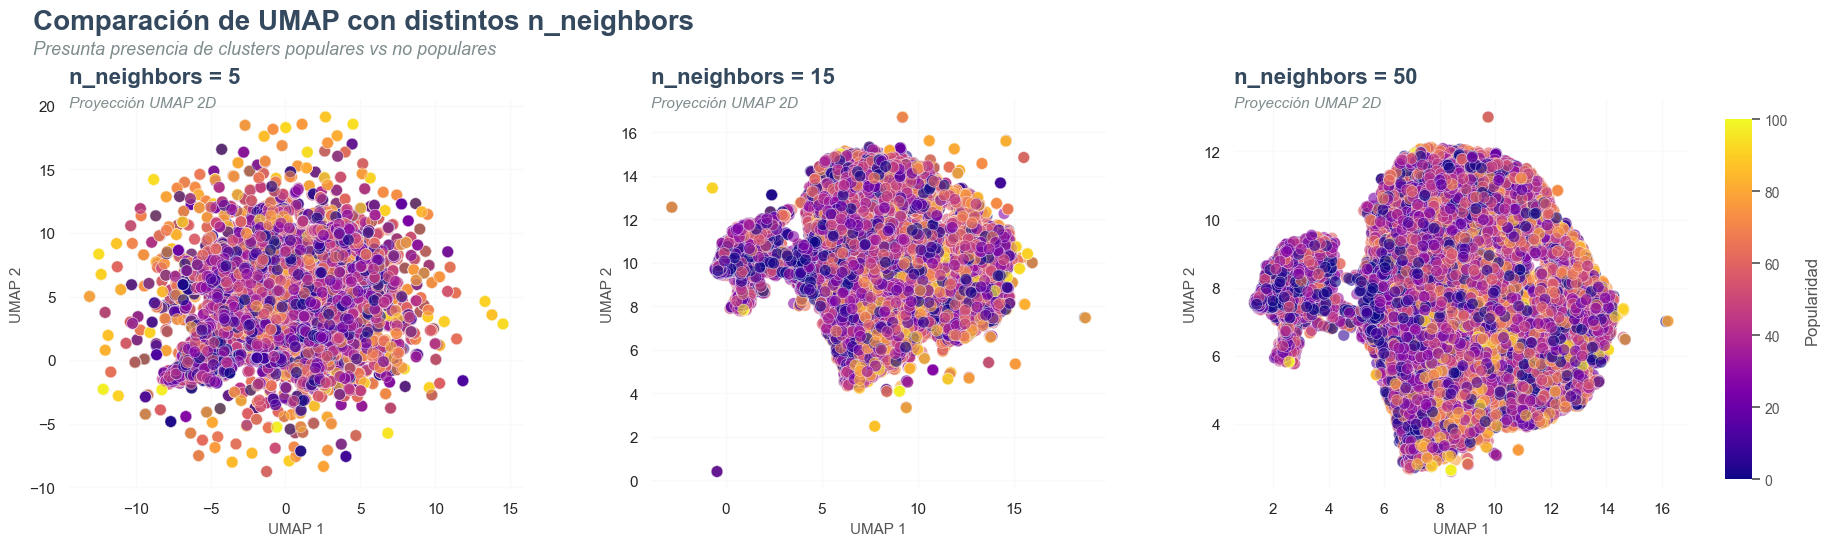

In [62]:
# --- ESTILO EDITORIAL ---
sns.set_theme(style="white")
plt.rcParams['font.family'] = 'sans-serif'

y = df['track_popularity'].values

# Colormap continuo: plasma va de morado oscuro → naranja → amarillo
cmap  = plt.cm.plasma
norm  = plt.Normalize(vmin=y.min(), vmax=y.max())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Títulos editoriales a nivel de figura
fig.text(0.04, 1.02, "Comparación de UMAP con distintos n_neighbors",
         fontsize=20, fontweight='bold', color='#34495e')
fig.text(0.04, 0.97,
         "Presunta presencia de clusters populares vs no populares",
         fontsize=13, color='#7f8c8d', style='italic')

for i, nn in enumerate(n_neighbors_vals):
    ax = axes[i]
    data_coords = resultados_umap[nn]

    ax.grid(color='#f8f9f9', linestyle='-', linewidth=1, zorder=0)

    sc = ax.scatter(
        data_coords[:, 0],
        data_coords[:, 1],
        c=y,               # variable continua como color
        cmap=cmap,
        norm=norm,
        alpha=0.6,
        s=70,
        edgecolors='white',
        linewidths=0.4,
        zorder=2
    )

    ax.set_title(f'n_neighbors = {nn}', loc='left',
                 fontweight='bold', fontsize=16, color='#34495e', pad=12)
    ax.text(0, 0.98, "Proyección UMAP 2D",
            transform=ax.transAxes, fontsize=11, color='#7f8c8d', style='italic')

    ax.set_xlabel('UMAP 1', fontsize=11, color='#555555')
    ax.set_ylabel('UMAP 2', fontsize=11, color='#555555')

    sns.despine(ax=ax, left=True, bottom=True)

# --- BARRA DE COLOR COMPARTIDA ---
# Agrega un eje estrecho a la derecha de la figura para la colorbar
cbar_ax  = fig.add_axes([0.98, 0.12, 0.015, 0.72])   # [left, bottom, width, height]
cbar     = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), cax=cbar_ax)
cbar.set_label('Popularidad', fontsize=12, color='#555555', labelpad=12)
cbar.ax.tick_params(labelsize=10, colors='#555555')
cbar.outline.set_visible(False)   # sin borde en la barra → limpio

plt.subplots_adjust(top=0.88, wspace=0.28, left=0.06, right=0.96, bottom=0.10)
plt.show()

## 2.2 Resultados importantes EDA1

* Univariado:
    - La popularidad es una variable dispersa, cuya probabilidad de ser un valor alto es un poco menor, ademas lo mas comun es que el indice de popularidad sea 0 (es la moda y se ve claramente el pico en el histograma), es decir es muy comun fracasar y son pocos los casos de exito

    - La industria suele utilizar canciones que duren en torno a los 3.6 minutos.

    - El valor medio de tempo es 120.88, la desviación estandar es relativamente baja respecto a la escala de la variable y el 50 % central está entre [99,96, 133,918], por lo que dicho rango indica **BPM** óptimos según la industria.

    - La industria musical, en general, parece seguir la tendencia de pistas con una energía relativamente alta.

    - El resto de variables no se pone en este documento ya que no dan información tan interpretable, sin embargo se usaran debido a su importancia para describir una pista de audio, para mas detalles sobre cada variable consulte el archivo `notebooks\EDA_&_1st_part_notebook.ipynb`. Sin embargo su uso o desuso se desidira posteriormente con tecnicas de selección de características.
* Bivariado:
    - No existe una variable que presente una relación especialmente fuerte con la popularidad.

    - Por lo general, las canciones populares (índice de popularidad > 50) suelen tener una energía ligeramente más baja que las no populares; por lo tanto, es preferible que la canción no se perciba como excesivamente ruidosa o extrema, buscando un equilibrio en la producción para llegar a un estilo ni muy lento o aburrido, pero tampoco extremadamente ruidoso.

* Multicolinealidad:
    - La variable `energy` tiene una alta correlación con `acousticness` (-0.49) y con `loudness` (0.66) lo cual podria implicar multicolinealidad, sin embargo al calcular el VIF ninguna presenta un VIF preocupante ($>5$), por lo que no es necesario considerar tratamientos de multicolinealidad.

* Outliers:
    - Se identifico que la variable cuya proporción de atipicos es mayor es `speechiness` ($9.67\%$), sin embargo, es de esperar y natural, debido a que las observaciones que posean una **speechiness** > 0,6 corresponden a contenidos hablados como pódcast, lo cual no es de interés en este caso, por lo que dichos valores tendrán que ser eliminados. Los valores por debajo de ese tope sería apropiado conservarlos, ya que probablemente correspondan a géneros altamente hablados como el rap o el hip-hop.

    - Otra variable con una cantidad considerable de atipicos es `acousticness` los outliers se pueden interpretar como la baja cantidad de canciones de las cual se tiene una alta calidad de confianza de que son acusticas (valor mayor a 0,5), lo cual indica que pistas altamente acusticas son poco comunes en la muestra.

    - LOF bajo todas las variables, solo registro **97** entradas atipicas que pueden ser eliminados o conservados, lo cual será evaluado más tarde en el proyecto.

* Exploración de  estructura:
    - Aplicando UMAP con **`n_neighbors` = 15 no se logro obtener mas de un cluster claro**, a lo mucho hay una "protuberancia" con `n_neighbors` = 15 y `n_neighbors` = 50 la cual puede difrenciarse muy poco con respecto al cluster principal y no es realmente determinante. **Es decir no hay una estructura clara separe los datos segun la popularidad (sin conocerla).**

    - Al **colorear segun la popularidad** no se observa una diferencia del color entre la masa principal y la "protuberancia". Esto se terminara de confirmar cuando se realice LDA bajo la variable que se plantea `is_popular`.

    - **Nota:** Por la naturaleza de borrador de esta proyección de UMAP aun debe tomarse por pinzas, ya que para generar dicha proyección se uso una versión escalada del dataset con StandardScaler aun ante presencia de atipicos y variables sesgadas, lo cual pudo alterar el resultado, en una fase posterior del proyecto se definira de manera mas clara que escalador usar (se podria considerar RobustScaler dado la naturaleza sesgada de algunas variables, en especial por el pico en 0 que tiene la popularidad), como tratar la asimetria antes del escalado (si se usará StandardScaler) y como tratar los atipicos (ej: eliminar los podcast).

    - **Nota2:** Se elimino la variable `mode` (naturalmente para el calculo tampoco se tomo la targuet) del calculo de la proyección para evitar una separación artificial por su naturaleza binaria.

    - Ademas tambien se usará un LDA basado en la variable binaria `is_popular` planteada, con el fin de evaluar la separación de grupos bajo ese otro metodo.


## 2.3 Posibles conclusiones

Dados los resultados obtenidos hasta el momento se puede intuir que lo mas seguro en la industria es el fracaso de una canción, sin embargo hay reglas que la industria en genral parece seguir, como lo son la duración de las canciones, el tempo, energia, etc. cuyo seguimiento puede potenciar la popularidad. Por lo cual se vuelve una opción especialmente interesante hacer uso de técnicas de mineria de patrones.

Adicionalmente, se evidencia que la popularidad no depende de una sola variable (no tiene una relacion directa con ninguna), lo cual sugiere que para poder predecir esta se tendrá que hallar alguna relación compleja en los datos que permita conocerla, no obstante, ante la dificultad de UMAP de hallar alguna estructura que separe los datos el objetivo parece complicarse, sin embargo esto podria cambiar bajo el uso de LDA que se ha planteado como hipotesis hasta el momento.

# Calidad General

## Diagnostico de datos faltantes

In [63]:
df.isnull().sum()

track_name                  5
track_artist                5
track_popularity            0
track_album_name            5
track_album_release_date    0
playlist_name               0
playlist_genre              0
playlist_subgenre           0
danceability                0
energy                      0
key                         0
loudness                    0
mode                        0
speechiness                 0
acousticness                0
instrumentalness            0
valence                     0
tempo                       0
duration_ms                 0
dtype: int64

In [64]:
df_nulos = df[df.isnull().any(axis=1)]
df_nulos

,track_name,track_artist,track_popularity,track_album_name,track_album_release_date,playlist_name,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,valence,tempo,duration_ms
8151,NaN,NaN,0,NaN,2012-01-05,HIP&HOP,rap,southern hip hop,0.714,0.821,6,-7.635,1,0.1760,0.0410,0.00000,0.649,95.999,282707
9282,NaN,NaN,0,NaN,2017-12-01,GANGSTA Rap,rap,gangster rap,0.678,0.659,11,-5.364,0,0.3190,0.0534,0.00000,0.191,146.153,202235
9283,NaN,NaN,0,NaN,2017-12-01,GANGSTA Rap,rap,gangster rap,0.465,0.820,10,-5.907,0,0.3070,0.0963,0.00000,0.505,86.839,206465
19568,NaN,NaN,0,NaN,2012-01-05,Reggaeton viejito🔥,latin,reggaeton,0.675,0.919,11,-6.075,0,0.0366,0.0606,0.00653,0.726,97.017,252773
19811,NaN,NaN,0,NaN,2012-01-05,latin hip hop,latin,latin hip hop,0.714,0.821,6,-7.635,1,0.1760,0.0410,0.00000,0.649,95.999,282707


Debido al bajo nivel de valores nulos se supone un mecanismo MCAR, ya que aquellos registros nulos son solo 5 y a todos ellos les hacen falta el nombre de la canción, el artista y el nombre del album, por ello se opta por su eliminación

In [65]:
df.dropna(inplace=True)

## Diagnostico y analisis de registros duplicados

In [66]:
df.duplicated().sum() # a primera vista no hay duplicados

np.int64(0)

In [76]:
# Definimos las columnas que mandan el criterio de duplicidad
columnas_clave = ['track_name', 'track_artist', 'track_popularity']

# Filtramos usando keep=False para ver TODAS las filas involucradas
df_revision = df[df.duplicated(subset=columnas_clave, keep="first")]

# Ordenamos para que los grupos de duplicados queden uno junto al otro
df_revision = df_revision.sort_values(by=columnas_clave)

len(df_revision), (len(df_revision)/len(df)) * 100

(0, 0.0)

In [68]:
df['num_playlists'] = df.groupby(columnas_clave).cumcount() + 1

df = df.sort_values(by=['track_name', 'track_artist', 'track_popularity', 'num_playlists'], ascending=[True, True, True, False])

df_final = df.drop_duplicates(subset=['track_name', 'track_artist', 'track_popularity'], keep='first')

# 3. (Opcional) Reordenar el índice si lo deseas
df_final = df_final.reset_index(drop=True)

df = df_final

En realidad hay 4586 registros duplicados (sin contar la primera ocurrencia) lo cual corresponde a un 23% de la base de datos, a pesar de eso se eliminaran, no obstante ya que los registros corresponden a la misma canción pero **vienen de una playlist diferente** puede ser realmente valioso para estimar la popularidad en base a en cuantas play list aparece, por lo cual se eliminan registros duplicados (menos la primera ocurrencia) y se genera una nueva variable `num_playlists` para definir en cuentas estaba, donde 1 es un registro unico y ese numero aumentará segun la cantidad de repeticiones que tenga.

/var/folders/bh/0zjq09yn1zz81yv_l3l5w2yh0000gn/T/ipykernel_28485/3161561173.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


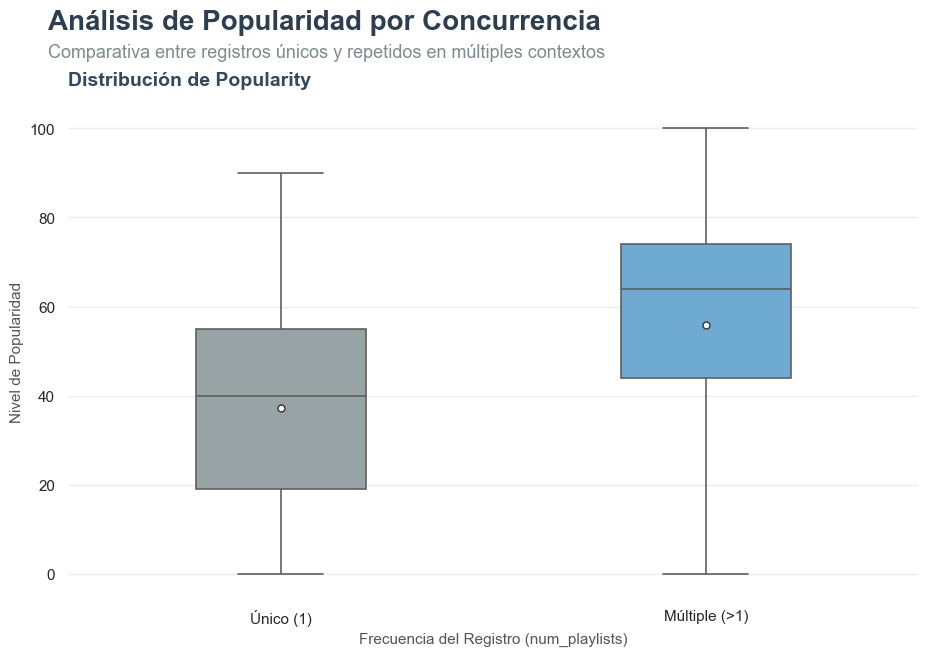

In [ ]:
# @title Grafico Playlist multiple vs unica
# --- 1. PREPARACIÓN DE DATOS ---
# Creamos la columna de segmentación (si no existe)
df['grupo_playlist'] = df['num_playlists'].apply(lambda x: 'Único (1)' if x == 1 else 'Múltiple (>1)')

# --- 2. CONFIGURACIÓN GLOBAL (Look Moderno) ---
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#555555'

# --- 3. CREAR FIGURA ---
fig, ax = plt.subplots(figsize=(10, 7))

# TÍTULO ESTILO EDITORIAL (Alineado a la izquierda)
fig.text(0.08, 0.96, "Análisis de Popularidad por Concurrencia", fontsize=20, fontweight='bold', color='#2c3e50')
fig.text(0.08, 0.92, "Comparativa entre registros únicos y repetidos en múltiples contextos", fontsize=13, color='#7f8c8d')

# Colores suaves (Flat UI)
colores = {'Único (1)': '#95a5a6', 'Múltiple (>1)': '#5dade2'}

# --- 4. DIBUJO Y PERSONALIZACIÓN ---

# Rejilla horizontal sutil
ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

# Dibujar Boxplot
sns.boxplot(
    data=df,
    x='grupo_playlist',
    y='track_popularity',
    ax=ax,
    palette=colores,
    width=0.4,
    linewidth=1.2,
    fliersize=3,
    showmeans=True,
    meanprops={
        "marker":"o",
        "markerfacecolor":"white",
        "markeredgecolor": "#333333",
        "markersize":"5",
        "zorder": 3
    },
    zorder=2
)

# Estética del Subplot
ax.set_title("Distribución de Popularity", loc='left', fontsize=14, fontweight='bold', pad=15, color='#34495e')
ax.set_ylabel("Nivel de Popularidad", fontsize=11, fontweight='medium')
ax.set_xlabel("Frecuencia del Registro (num_playlists)", fontsize=11, fontweight='medium')

# Eliminar bordes para el look 'flat'
sns.despine(ax=ax, left=True, bottom=True)

# Ajustar espacio para que los títulos respiren
plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.15)

plt.show()

In [75]:
df.columns # Recuerde eliminar grupo_playlist

Index(['track_name', 'track_artist', 'track_popularity', 'track_album_name',
       'track_album_release_date', 'playlist_name', 'playlist_genre',
       'playlist_subgenre', 'danceability', 'energy', 'key', 'loudness',
       'mode', 'speechiness', 'acousticness', 'instrumentalness', 'valence',
       'tempo', 'duration_ms', 'num_playlists', 'grupo_playlist'],
      dtype='str')

In [78]:
unico = df[df['num_playlists'] == 1]['track_popularity']
multiple = df[df['num_playlists'] > 1]['track_popularity']

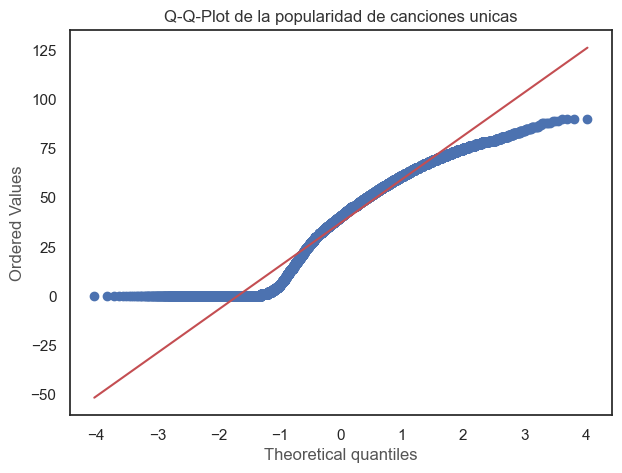

In [80]:
plt.figure(figsize=(7, 5))
stats.probplot(unico, dist="norm", plot=plt)
plt.title("Q-Q-Plot de la popularidad de canciones unicas")
plt.show()